In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


query = """SELECT  state_code,
        COUNT(*) AS total_new_issuances,
        ROUND(AVG(TRY_CAST(t.original_principal_balance AS FLOAT)), 2) As Average_OPB,
        SUM(TRY_CAST(t.original_principal_balance AS FLOAT)) AS Total_OPB,
        ROUND(AVG(TRY_CAST(t.loan_interest_rate AS FLOAT)), 2)AS Average_interest_rate,
        ROUND(AVG(TRY_CAST(t.credit_score AS FLOAT)), 0) As Average_credit_Score,
        SUM(CASE WHEN t.agency = 'F' THEN 1 ELSE 0 END) AS New_FHA_Issuances,
        SUM(CASE WHEN t.agency = 'V' THEN 1 ELSE 0 END) AS New_VA_Issuances,
        SUM(CASE WHEN t.agency = 'R' THEN 1 ELSE 0 END) AS New_RD_Issuances,
        SUM(CASE WHEN t.agency = 'N' THEN 1 ELSE 0 END) AS New_PIH_Issuances
FROM sf_new_issuance_loan_level t
JOIN issuer_info t2 ON t.issuer_id = t2.issuer_number
WHERE t.as_of_date = '8/1/2026'
GROUP BY t.state_code"""

df = read_sql(query)


print(df.head())

  state_code  total_new_issuances  average_opb     total_opb  \
0         AK                  420    422783.33  1.775690e+08   
1         AL                 4041    275271.47  1.112372e+09   
2         AR                 2044    238522.02  4.875390e+08   
3         AZ                 4462    366870.24  1.636975e+09   
4         CA                 7992    518452.20  4.143470e+09   

   average_interest_rate  average_credit_score  new_fha_issuances  \
0                   6.09                 720.0                130   
1                   6.03                 695.0               2290   
2                   6.07                 693.0               1153   
3                   5.84                 701.0               2872   
4                   6.01                 699.0               5645   

   new_va_issuances  new_rd_issuances  new_pih_issuances  
0               260                10                 20  
1              1518               232                  1  
2               681    

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_18052\1783494403.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'TX'),
  Text(1, 0, 'FL'),
  Text(2, 0, 'CA'),
  Text(3, 0, 'GA'),
  Text(4, 0, 'NC'),
  Text(5, 0, 'OH'),
  Text(6, 0, 'VA'),
  Text(7, 0, 'TN'),
  Text(8, 0, 'AZ'),
  Text(9, 0, 'IL')])

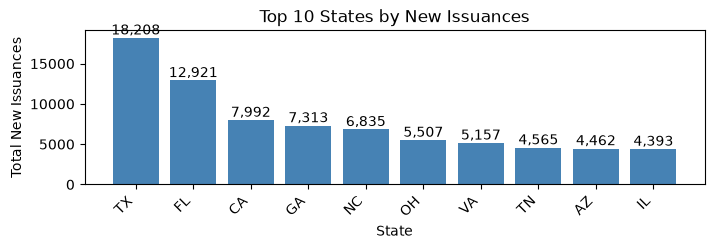

In [ ]:
top_states = df.nlargest(10,'total_new_issuances')

plt.figure(figsize=(10,2))
bars = plt.bar(top_states['state_code'], top_states['total_new_issuances'], color='steelblue',)
plt.bar_label(bars, fmt=lambda x: f'{int(x):,}')
plt.title('Top 10 States by New Issuances')
plt.xlabel('State')
plt.ylabel('Total New Issuances')
plt.xticks(rotation=45, ha='right')